# Copy, switch, and impute with a Li--Stephens HMM

We ask one question. A target haplotype resembles a mosaic of reference haplotypes. Which reference haplotype is copied at each marker, and what allele is likely at an untyped marker?

## Start from first principles

- Nearby alleles often share a copying source because of linkage disequilibrium.
- Recombination can change the copying source.
- Mutation, genotyping error, or model mismatch can change the observed allele.
- The copying source is hidden.

This worked example connects **haplotypes, linkage disequilibrium, recombination, phase, and imputation** with an **HMM, posterior probabilities, and a sum over hidden copying paths**.


## 1. Concept and intuition

Suppose we know a panel of phased reference haplotypes. At marker $s$, the hidden state $Z_s$ records **which reference haplotype is being copied**.

- Staying in the same state means continuing to copy the same donor.
- Changing state represents a historical recombination event.
- An observed allele usually matches the copied donor, but mutation, genotyping error, or model imperfection can produce a mismatch.

The worked example contains 20 reference haplotypes and 100 markers. A target haplotype is generated by copying the panel with occasional switches and mismatches, and only 30 markers are observed. The true copying path and the missing alleles are retained only for checking the answer.

In [1]:
set.seed(534)
M <- 100
K <- 20
typed_fraction <- 0.30
allele_frequency <- runif(M, 0.2, 0.8)

simulate_reference <- function(frequency, copy_probability = 0.70) {
  haplotype <- integer(length(frequency))
  haplotype[1] <- rbinom(1, 1, frequency[1])
  for (s in 2:length(haplotype)) {
    haplotype[s] <- if (runif(1) < copy_probability) {
      haplotype[s - 1]
    } else {
      rbinom(1, 1, frequency[s])
    }
  }
  haplotype
}

H <- replicate(K, simulate_reference(allele_frequency))
dimnames(H) <- list(marker = paste0("s", seq_len(M)),
                    haplotype = paste0("H", seq_len(K)))

true_path <- integer(M)
true_target <- integer(M)
current_donor <- sample.int(K, 1)
for (s in seq_len(M)) {
  if (s > 1 && runif(1) < 0.05) current_donor <- sample.int(K, 1)
  true_path[s] <- current_donor
  true_target[s] <- H[s, current_donor]
  if (runif(1) < 0.02) true_target[s] <- 1 - true_target[s]
}

typed <- sort(sample.int(M, round(typed_fraction * M)))
observed <- rep(NA_integer_, M)
observed[typed] <- true_target[typed]

cat(sprintf("Reference panel: %d haplotypes by %d markers\n", K, M))
cat(sprintf("Target: %d typed markers and %d markers to impute\n",
            length(typed), sum(is.na(observed))))

data.frame(
  marker = rownames(H)[1:12],
  H[1:12, 1:4],
  observed = ifelse(is.na(observed[1:12]), "?", observed[1:12]),
  truth_for_checking = true_target[1:12],
  true_donor_for_checking = colnames(H)[true_path[1:12]],
  check.names = FALSE
)

Reference panel: 20 haplotypes by 100 markers


Target: 30 typed markers and 70 markers to impute


,marker,H1,H2,H3,H4,observed,truth_for_checking,true_donor_for_checking
,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>
s1,s1,1,0,0,1,?,1,H4
s2,s2,1,0,1,1,1,1,H4
s3,s3,0,0,1,1,1,1,H4
s4,s4,0,1,1,1,?,1,H4
s5,s5,0,0,1,1,?,1,H4
s6,s6,0,0,1,1,1,1,H4
s7,s7,0,0,1,1,?,1,H4
s8,s8,0,0,1,1,?,1,H4
s9,s9,0,1,1,1,?,1,H4


## 2. Turn the copying idea into probabilities

The HMM is defined by three probability statements.

### Initial state

We treat all $K$ reference haplotypes as equally likely at the first marker.

$$P(Z_1=k)=1/K.$$

### Transition probability

Between adjacent markers, continue copying with probability $1-\rho$. With probability $\rho$, redraw a donor uniformly from the $K$ references.

$$P(Z_s=k\mid Z_{s-1}=j)=(1-\rho)\,I(k=j)+\frac{\rho}{K}.$$

A redraw may select the same donor again. Every row of the transition matrix therefore sums to one. A full Li--Stephens model lets $\rho$ vary with genetic distance and reference-panel size. Here it is fixed so that the idea remains visible.

### Emission probability

If the observed allele is $x_s$ and reference haplotype $k$ carries $H_{sk}$,

$$P(x_s\mid Z_s=k)=\begin{cases}1-\epsilon,&x_s=H_{sk},\\ \epsilon,&x_s\neq H_{sk}.\end{cases}$$

At an untyped marker there is no emission evidence, so every state receives emission probability 1.

In [2]:
rho <- 0.01       # probability of redrawing the donor
epsilon <- 0.01   # probability of an allele mismatch

transition <- (1 - rho) * diag(K) + (rho / K) * matrix(1, K, K)
dimnames(transition) <- list(from = colnames(H), to = colnames(H))

emission <- matrix(1, nrow = M, ncol = K,
                   dimnames = list(marker = rownames(H), state = colnames(H)))
for (s in typed) {
  emission[s, ] <- ifelse(H[s, ] == observed[s], 1 - epsilon, epsilon)
}

stopifnot(all(abs(rowSums(transition) - 1) < 1e-12))
data.frame(
  probability = c("stay with H1", "redraw to H2", "row sum"),
  value = c(transition[1, 1], transition[1, 2], sum(transition[1, ]))
)
head(data.frame(marker = rownames(H), observed, emission[, 1:4]), 12)

probability,value
<chr>,<dbl>
stay with H1,0.9905
redraw to H2,0.0005
row sum,1.0000


,marker,observed,H1,H2,H3,H4
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
s1,s1,NA,1.00,1.00,1.00,1.00
s2,s2,1,0.99,0.01,0.99,0.99
s3,s3,1,0.01,0.01,0.99,0.99
s4,s4,NA,1.00,1.00,1.00,1.00
s5,s5,NA,1.00,1.00,1.00,1.00
s6,s6,1,0.01,0.01,0.99,0.99
s7,s7,NA,1.00,1.00,1.00,1.00
s8,s8,NA,1.00,1.00,1.00,1.00
s9,s9,NA,1.00,1.00,1.00,1.00


## 3. Sum over the hidden copying paths

There are $K^M$ possible copying paths. This example already has $20^{100}$ paths, so direct enumeration is impossible.

The forward probability carries evidence from the left,

$$\alpha_s(k)=P(x_{1:s},Z_s=k),$$

and the backward probability carries evidence from the right,

$$\beta_s(k)=P(x_{s+1:M}\mid Z_s=k).$$

Combining them gives the posterior copying probability

$$P(Z_s=k\mid x_{1:M})\propto\alpha_s(k)\beta_s(k).$$

Forward--backward reuses the same partial sums and therefore sums over all paths in time proportional to the number of markers. This is **dynamic programming**. Scaling prevents numerical underflow without changing the posterior probabilities.

In [3]:
forward_backward <- function(emission, transition, initial = NULL) {
  M <- nrow(emission)
  K <- ncol(emission)
  if (is.null(initial)) initial <- rep(1 / K, K)

  alpha <- matrix(0, M, K, dimnames = dimnames(emission))
  beta <- matrix(0, M, K, dimnames = dimnames(emission))
  normalizer <- numeric(M)

  alpha[1, ] <- initial * emission[1, ]
  normalizer[1] <- sum(alpha[1, ])
  alpha[1, ] <- alpha[1, ] / normalizer[1]

  for (s in 2:M) {
    alpha[s, ] <- as.numeric(alpha[s - 1, ] %*% transition) * emission[s, ]
    normalizer[s] <- sum(alpha[s, ])
    alpha[s, ] <- alpha[s, ] / normalizer[s]
  }

  beta[M, ] <- 1
  for (s in rev(seq_len(M - 1))) {
    beta[s, ] <- as.numeric(transition %*% (emission[s + 1, ] * beta[s + 1, ]))
    beta[s, ] <- beta[s, ] / normalizer[s + 1]
  }

  posterior <- alpha * beta
  posterior <- posterior / rowSums(posterior)

  list(alpha = alpha, beta = beta, posterior = posterior,
       log_likelihood = sum(log(normalizer)))
}

fit <- forward_backward(emission, transition)
stopifnot(all(abs(rowSums(fit$posterior) - 1) < 1e-10))
cat(sprintf("Log-likelihood: %.2f\n", fit$log_likelihood))

Log-likelihood: -23.49


## 4. Read the posterior copying path

The heatmap below shows the posterior probability of each reference haplotype at each marker. A high posterior probability marks a plausible donor after using **all** typed markers on both sides.

The black line is the simulated copying path, retained as a control. The most probable donor need not always be the true donor because several reference haplotypes can carry the same local allele pattern.

exact_donor_matches,total_markers,median_probability_of_true_donor
<int>,<dbl>,<dbl>
28,100,0.3301232


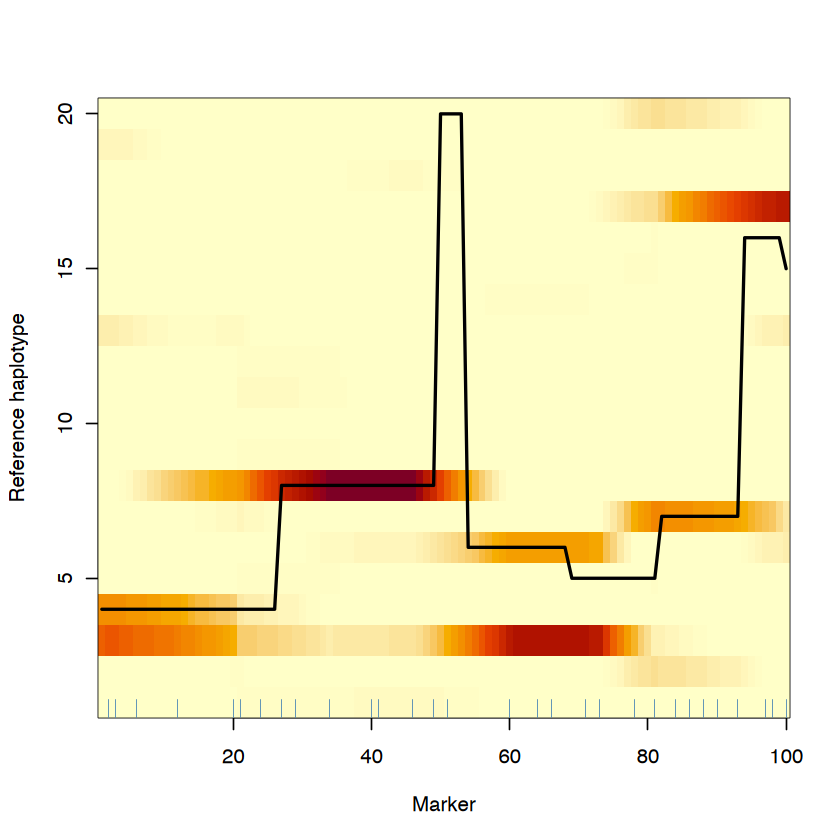

In [4]:
posterior_path <- max.col(fit$posterior, ties.method = "first")
true_path_probability <- fit$posterior[cbind(seq_len(M), true_path)]

data.frame(
  exact_donor_matches = sum(posterior_path == true_path),
  total_markers = M,
  median_probability_of_true_donor = median(true_path_probability)
)

image(seq_len(M), seq_len(K), fit$posterior, useRaster = TRUE,
      col = hcl.colors(40, "YlOrRd", rev = TRUE),
      xlab = "Marker", ylab = "Reference haplotype")
lines(seq_len(M), true_path, lwd = 2)
rug(typed, side = 1, col = "steelblue")


## 5. Impute a missing allele

At an untyped marker, the observed allele contributes no emission information. But typed markers nearby tell us which donor is likely. We average the reference alleles using the posterior copying probabilities:

$$P(x_s=1\mid x_{\mathrm{typed}})=\sum_{k=1}^{K}P(Z_s=k\mid x_{\mathrm{typed}})H_{sk}.$$

This posterior probability is an allele **dosage** between 0 and 1. Thresholding at 0.5 gives a hard call, but the dosage retains uncertainty and is usually the more informative output.

In [5]:
probability_allele_1 <- rowSums(fit$posterior * H)
imputed_call <- ifelse(is.na(observed), as.integer(probability_allele_1 >= 0.5), observed)

imputation_table <- data.frame(
  marker = rownames(H),
  observed = ifelse(is.na(observed), "?", observed),
  P_allele_1 = round(probability_allele_1, 3),
  imputed_or_observed = imputed_call,
  truth_for_checking = true_target
)
missing <- which(is.na(observed))
correct <- imputed_call[missing] == true_target[missing]
head(imputation_table[missing, ], 12)
cat(sprintf("Missing alleles correctly imputed: %d of %d (%.1f%%)\n",
            sum(correct), length(correct), 100 * mean(correct)))
stopifnot(all(probability_allele_1 >= 0 & probability_allele_1 <= 1))
stopifnot(all(imputed_call[typed] == observed[typed]))

,marker,observed,P_allele_1,imputed_or_observed,truth_for_checking
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
s1,s1,?,0.528,1,1
s4,s4,?,0.888,1,1
s5,s5,?,0.870,1,1
s7,s7,?,0.938,1,1
s8,s8,?,0.816,1,1
s9,s9,?,0.949,1,1
s10,s10,?,0.997,1,1
s11,s11,?,0.987,1,1
s13,s13,?,0.553,1,1


Missing alleles correctly imputed: 62 of 70 (88.6%)


## What to remember

1. **Concept and intuition.** A haplotype that is a simple mosaic of reference haplotypes receives high probability. Switches represent past recombination, and mismatches allow mutation or error.
2. **Insight behind the approach.** Transition and emission probabilities define the copying process. Forward--backward sums over all hidden copying paths.
3. **Worked example.** Typed markers identify likely paths through the reference panel. Posterior copying probabilities then give an allele dosage at each untyped marker.

The copying process is a tractable approximation to shared ancestry and recombination.

### Scope of this notebook

This example uses one phased haploid target so that one copying path remains visible. Diploid genotype imputation uses two unknown paths through the reference panel and jointly addresses haplotype phase. Full models also use genetic distance, larger panels, and genotype uncertainty.

### Source record and further detail

- The simulation uses seed 534, 20 reference haplotypes, 100 markers, and a typed fraction of 0.30.
- The transition matrix uses $(1-\rho)I+(\rho/K)\mathbf{1}\mathbf{1}^{T}$. It implements Pritchard's generate-or-redraw description and guarantees that every row sums to one.
- Pritchard, *An Owner's Guide to the Human Genome*, Chapter 2.3, especially the haplotype-copying and phasing/imputation sections.
- Li and Stephens (2003), *Modeling Linkage Disequilibrium and Identifying Recombination Hotspots Using Single-Nucleotide Polymorphism Data*.